In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

df1 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202505.csv")
df2 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202506.csv")
df3 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202507.csv")
df4 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202508.csv")
df5 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202509.csv")
df6 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202510.csv")
df7 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202511.csv")
df8 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202512.csv")
df9 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202601.csv")
df10 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202602.csv")
df11 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202603.csv")
df12 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202604.csv")
df13 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202605.csv")


/tmp/ipykernel_27704/3312040348.py:4: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202506.csv")
/tmp/ipykernel_27704/3312040348.py:11: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df9 = pd.read_csv("/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/data/CRMLSSold202601.csv")


In [4]:
df_original = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12, df13], ignore_index=True)
df = df_original.copy()

In [5]:
print(df.columns)

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

#**EDA**
With **ClosePrice(Target Variable), LivingArea, Bedrooms, Bathrooms, and LotSize**

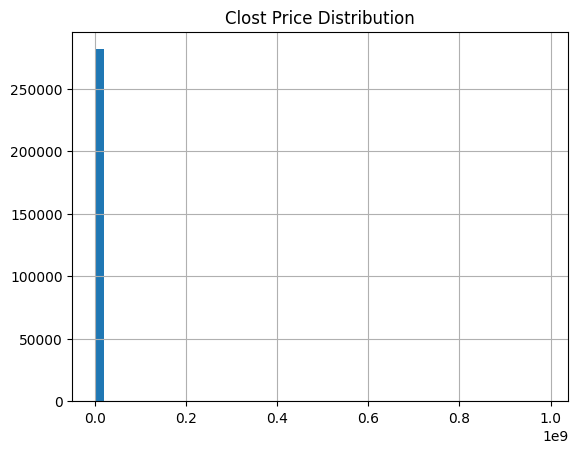

In [6]:
df['ClosePrice'].hist(bins=50)
plt.title("Clost Price Distribution")
plt.show()

In [7]:
df['ClosePrice'].describe()

,ClosePrice
count,2.818200e+05
mean,9.144514e+05
std,7.465235e+06
min,0.000000e+00
25%,3.500000e+04
50%,6.250000e+05
75%,1.065000e+06
max,9.895000e+08


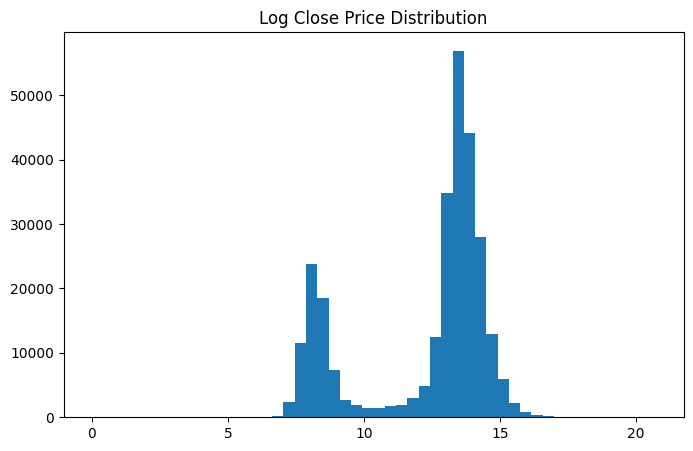

In [8]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['ClosePrice']), bins=50)
plt.title("Log Close Price Distribution")
plt.show()

### **NOTES**

The ClosePrice distribution is highly right-skewed. As we can see in the above describe information, the median price is \$625,000 while the mean is around \$914,000, indicating the presence of high-value outliers. The dataset also contains properties with a ClosePrice of 0 and maximum value of \$989.5 million, which should be investigated during data cleaning.

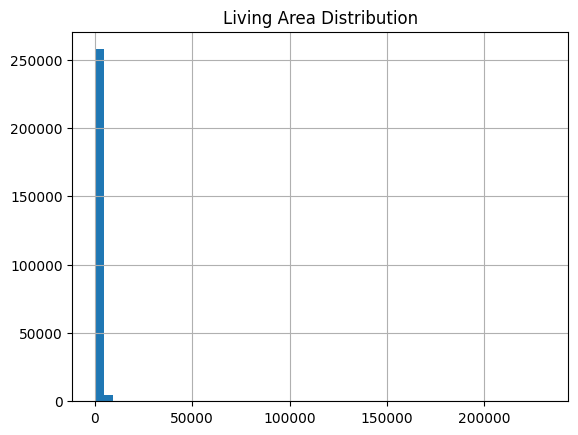

In [9]:
df['LivingArea'].hist(bins=50)
plt.title("Living Area Distribution")
plt.show()

In [10]:
df['LivingArea'].describe()

,LivingArea
count,262492.000000
mean,1818.522015
std,1317.244186
min,0.000000
25%,1181.000000
50%,1583.000000
75%,2163.000000
max,231545.000000


In [11]:
df[df['LivingArea'] == 0].shape

(231, 78)

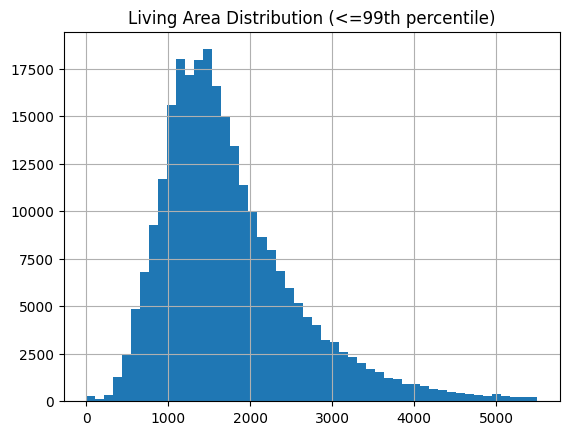

In [12]:
df[df['LivingArea'] <= df['LivingArea'].quantile(0.99)]['LivingArea'].hist(bins=50)
plt.title("Living Area Distribution (<=99th percentile)")
plt.show()

### **NOTES**

The LivingArea distribution is right-skewed. Most homes are ranging from around 800 to 2,500 sqft. The median LivingArea is 1,583 sqft, while the mean is around 1,819 sqft. The dataset contains several extreme outliers, including a maximum value of 231,545 sqft, as well as 231 records with a LivingArea of 0 sqft. These values should be reviewed during data cleaning.

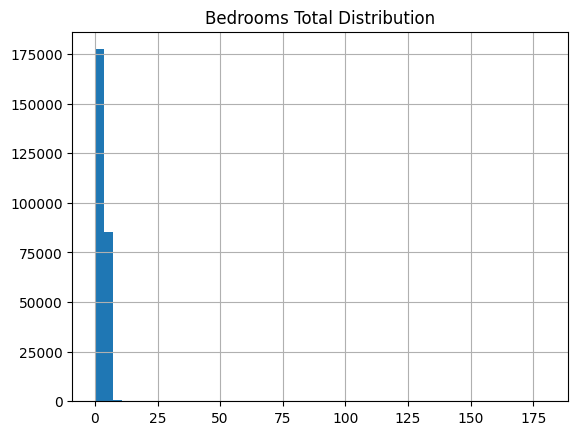

In [13]:
df['BedroomsTotal'].hist(bins=50)
plt.title("Bedrooms Total Distribution")
plt.show()

In [14]:
df['BedroomsTotal'].describe()

,BedroomsTotal
count,263787.000000
mean,3.091309
std,1.503186
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,180.000000


In [15]:
df['BedroomsTotal'].value_counts().sort_index()

,count
BedroomsTotal,
0.0,2279
1.0,15865
2.0,61790
3.0,97467
4.0,62665
...,...
81.0,1
95.0,1
99.0,1


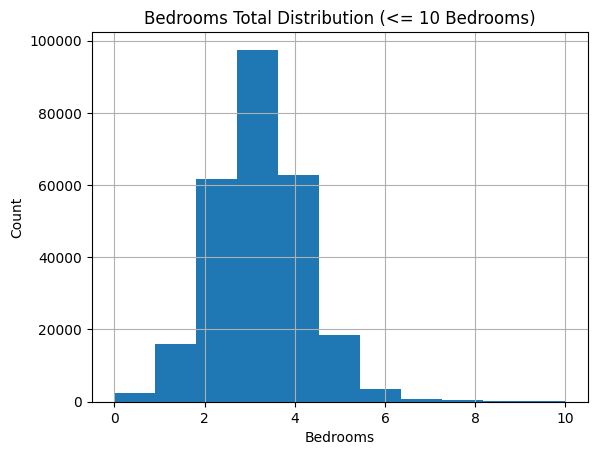

In [16]:
df[df['BedroomsTotal'] <= 10]['BedroomsTotal'].hist(bins=11)

plt.title("Bedrooms Total Distribution (<= 10 Bedrooms)")
plt.xlabel("Bedrooms")
plt.ylabel("Count")
plt.show()

### **NOTES**

The BedroomsTotal distribution is concentrated around 3-bedroom homes, with most properties containing between 2 and 4 bedrooms. The dataset contains several extreme outliers, including a maximum value of 180 bedrooms, as well as 2,279 records with a BedroomsTotal of 0. These values should be reviewed during data cleaning.

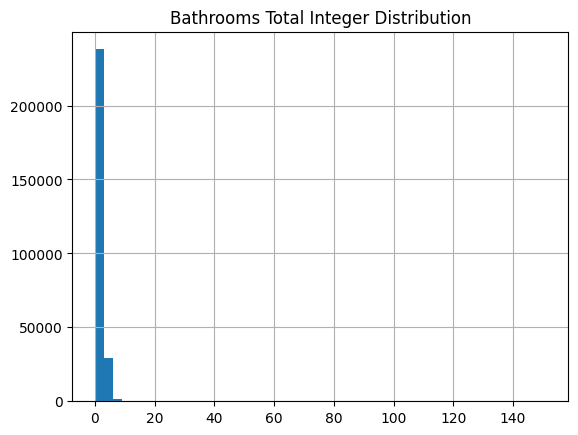

In [17]:
df['BathroomsTotalInteger'].hist(bins=50)
plt.title("Bathrooms Total Integer Distribution")
plt.show()

In [18]:
df['BathroomsTotalInteger'].describe()

,BathroomsTotalInteger
count,269412.000000
mean,2.458083
std,1.482158
min,0.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,151.000000


In [19]:
df['BathroomsTotalInteger'].value_counts().sort_index()

,count
BathroomsTotalInteger,
0.0,5856
1.0,38039
2.0,111024
3.0,83119
4.0,19141
...,...
83.0,1
96.0,1
99.0,1


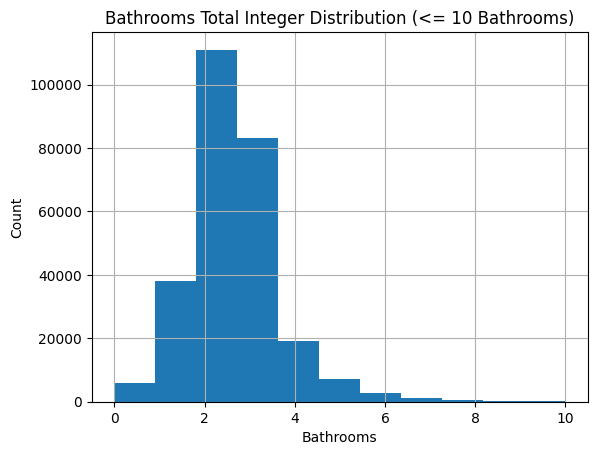

In [20]:
df[df['BathroomsTotalInteger'] <= 10]['BathroomsTotalInteger'].hist(bins=11)

plt.title("Bathrooms Total Integer Distribution (<= 10 Bathrooms)")
plt.xlabel("Bathrooms")
plt.ylabel("Count")
plt.show()

### **NOTES**

The BathroomsTotalInteger distribution is concentrated around 2-bathroom homes, with most properties containing between 1 and 3 bathrooms. The dataset contains several extreme outliers, including a maximum value of 151 bathrooms, as well as 5,856 records with a BathroomsTotalInteger of 0. These values should be reviewed during data cleaning.

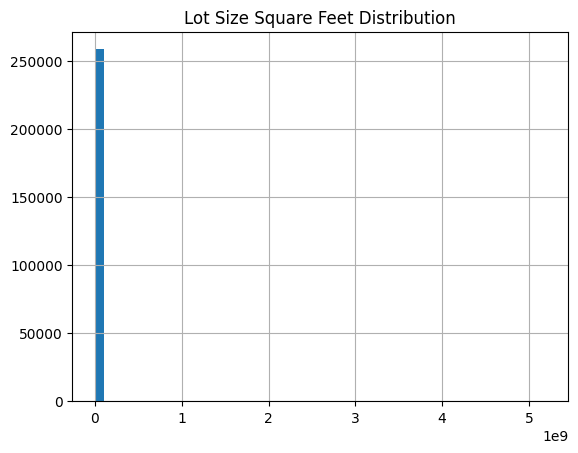

In [21]:
df['LotSizeSquareFeet'].hist(bins=50)
plt.title("Lot Size Square Feet Distribution")
plt.show()

In [22]:
df['LotSizeSquareFeet'].describe()

,LotSizeSquareFeet
count,2.586050e+05
mean,5.490331e+05
std,2.310665e+07
min,0.000000e+00
25%,5.227000e+03
50%,7.405000e+03
75%,1.367100e+04
max,5.193920e+09


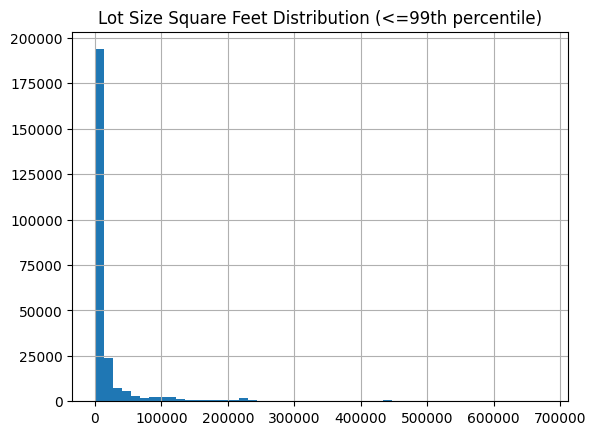

In [23]:
df[df['LotSizeSquareFeet'] <= df['LotSizeSquareFeet'].quantile(0.99)]['LotSizeSquareFeet'].hist(bins=50)
plt.title("Lot Size Square Feet Distribution (<=99th percentile)")
plt.show()

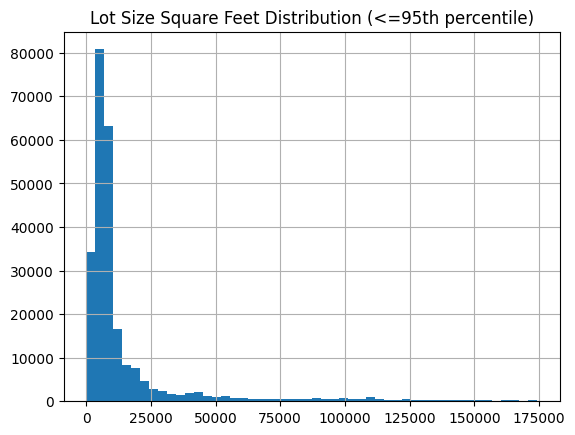

In [24]:
df[df['LotSizeSquareFeet'] <= df['LotSizeSquareFeet'].quantile(0.95)]['LotSizeSquareFeet'].hist(bins=50)
plt.title("Lot Size Square Feet Distribution (<=95th percentile)")
plt.show()

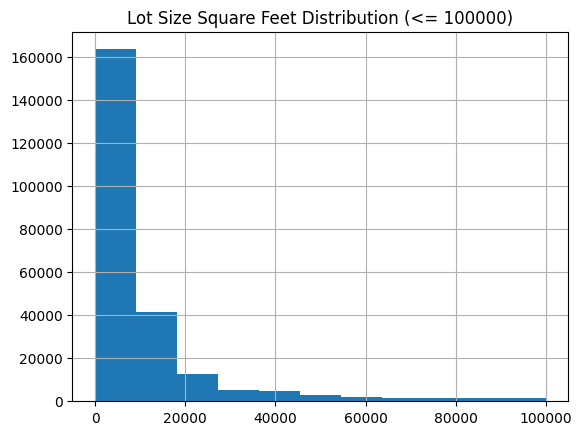

In [25]:
df[df['LotSizeSquareFeet'] <= 100000]['LotSizeSquareFeet'].hist(bins=11)
plt.title("Lot Size Square Feet Distribution (<= 100000)")
plt.show()

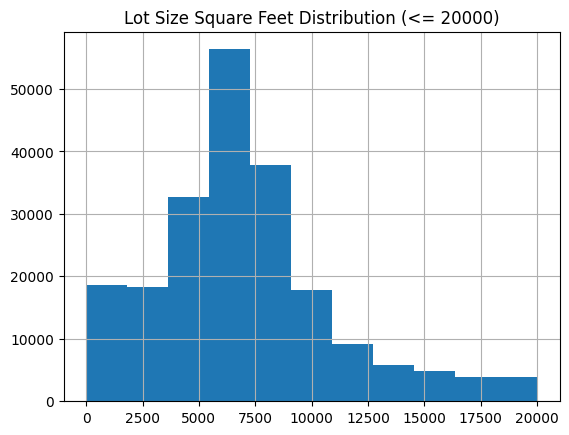

In [26]:
df[df['LotSizeSquareFeet'] <= 20000]['LotSizeSquareFeet'].hist(bins=11)
plt.title("Lot Size Square Feet Distribution (<= 20000)")
plt.show()

### **NOTES**

The LotSizeSquareFeet distribution is highly right-skewed. Most properties occupy relatively small lots, typically between 3,000 and 11,000 square feet, while a small number of extremely large parcels create a long right tail. The presence of zero-valued records and extreme outliers indicates that data cleaning will be necessary before modeling.

In [27]:
df_sf = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

In [28]:
print("Original dataset:", df.shape)
print("Filtered dataset:", df_sf.shape)

Original dataset: (281823, 78)
Filtered dataset: (141997, 78)


## **Lot & Financial Information Variables' EDA**

In [29]:
financial_features = [
    "ListPrice", "OriginalListPrice", "ClosePrice",
    "TaxAnnualAmount", "TaxYear",
    "AssociationFee", "AssociationFeeFrequency",
    "LotSizeAcres", "LotSizeArea", "LotSizeSquareFeet",
    "LotSizeDimensions"
]

In [30]:
missing = pd.DataFrame({
    "Missing Count": df_sf[financial_features].isna().sum(),
    "Missing %": (df_sf[financial_features].isna().mean()*100).round(2)
})

missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
TaxAnnualAmount,141997,100.00
TaxYear,141997,100.00
LotSizeDimensions,133007,93.67
AssociationFeeFrequency,105853,74.55
AssociationFee,41364,29.13
LotSizeSquareFeet,2433,1.71
LotSizeAcres,2434,1.71
LotSizeArea,2420,1.70
OriginalListPrice,296,0.21
ClosePrice,0,0.00


In [31]:
df_sf[financial_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 141997 entries, 8 to 281819
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   ListPrice                141997 non-null  float64
 1   OriginalListPrice        141701 non-null  float64
 2   ClosePrice               141997 non-null  float64
 3   TaxAnnualAmount          0 non-null       float64
 4   TaxYear                  0 non-null       float64
 5   AssociationFee           100633 non-null  float64
 6   AssociationFeeFrequency  36144 non-null   object 
 7   LotSizeAcres             139563 non-null  float64
 8   LotSizeArea              139577 non-null  float64
 9   LotSizeSquareFeet        139564 non-null  float64
 10  LotSizeDimensions        8990 non-null    object 
dtypes: float64(9), object(2)
memory usage: 13.0+ MB


In [32]:
num_features = [
    "ListPrice",
    "OriginalListPrice",
    "ClosePrice",
    "AssociationFee",
    "LotSizeAcres",
    "LotSizeArea",
    "LotSizeSquareFeet"
]

df_sf[num_features].describe().T

,count,mean,std,min,25%,50%,75%,max
ListPrice,141997.0,1.266758e+06,1.601979e+06,8000.0,625000.00,895000.0000,1399900.00,1.375000e+08
OriginalListPrice,141701.0,1.384373e+06,7.942335e+06,0.0,638000.00,899000.0000,1449000.00,1.302000e+09
ClosePrice,141997.0,1.344654e+06,8.084465e+06,0.0,625000.00,890000.0000,1425000.00,9.895000e+08
AssociationFee,100633.0,1.064366e+02,3.453149e+02,0.0,0.00,0.0000,130.00,2.071200e+04
LotSizeAcres,139563.0,1.402384e+01,7.850556e+02,0.0,0.13,0.1674,0.24,1.276310e+05
LotSizeArea,139577.0,1.836091e+04,2.013154e+05,0.0,5413.00,7100.0000,10000.00,4.379087e+07
LotSizeSquareFeet,139564.0,3.710659e+05,1.744801e+07,0.0,5663.00,7289.0000,10454.00,1.938943e+09


In [33]:
cat_features = [
    "AssociationFeeFrequency",
    "LotSizeDimensions"
]

In [34]:
for col in cat_features:
    print(col)
    print(df_sf[col].value_counts(dropna=False))
    print()

AssociationFeeFrequency
AssociationFeeFrequency
NaN             105853
Monthly          31756
Annually          2801
Quarterly         1376
SemiAnnually       211
Name: count, dtype: int64

LotSizeDimensions
LotSizeDimensions
NaN                133007
50x135                175
50x100                115
50x130                105
50x150                 97
                    ...  
31400                   1
7930                    1
5151                    1
53x148                  1
173x183x162x129         1
Name: count, Length: 5172, dtype: int64



In [35]:
important_features = [
    "ListPrice",
    "ClosePrice",
    "OriginalListPrice",
    "LotSizeSquareFeet",
    "AssociationFee"
]

In [36]:
df_sf["ListPrice"].describe()

,ListPrice
count,1.419970e+05
mean,1.266758e+06
std,1.601979e+06
min,8.000000e+03
25%,6.250000e+05
50%,8.950000e+05
75%,1.399900e+06
max,1.375000e+08


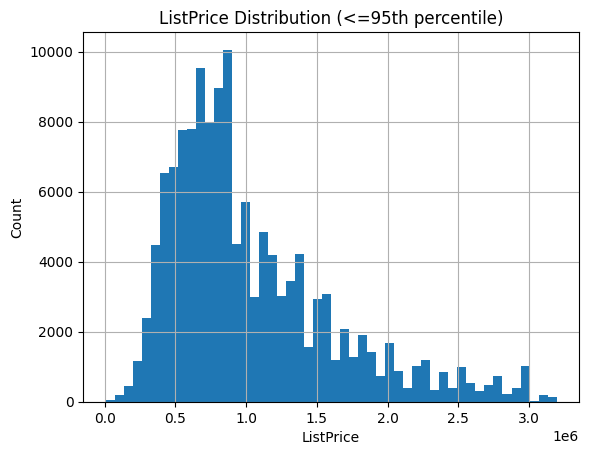

In [37]:
df_sf[df_sf["ListPrice"] <= df_sf["ListPrice"].quantile(0.95)]["ListPrice"].hist(bins=50)
plt.title("ListPrice Distribution (<=95th percentile)")
plt.xlabel("ListPrice")
plt.ylabel("Count")
plt.show()

### **NOTES**

ListPrice is highly right-skewed, and most properties are listed below the 95th percentile.

In [38]:
df_sf["OriginalListPrice"].describe()

,OriginalListPrice
count,1.417010e+05
mean,1.384373e+06
std,7.942335e+06
min,0.000000e+00
25%,6.380000e+05
50%,8.990000e+05
75%,1.449000e+06
max,1.302000e+09


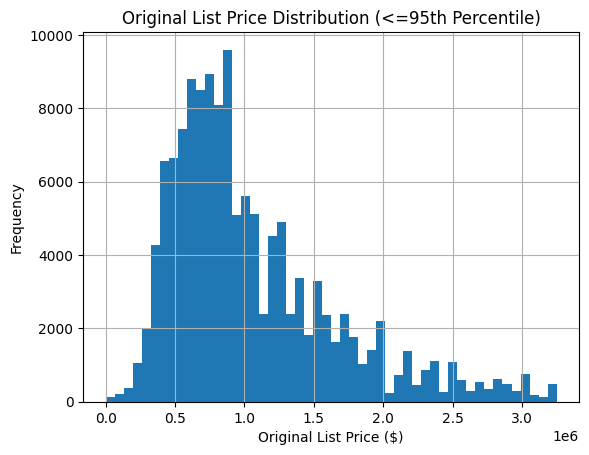

In [39]:
df_sf[
    df_sf["OriginalListPrice"] <= df_sf["OriginalListPrice"].quantile(0.95)
]["OriginalListPrice"].hist(bins=50)

plt.title("Original List Price Distribution (<=95th Percentile)")
plt.xlabel("Original List Price ($)")
plt.ylabel("Frequency")
plt.show()

### **NOTES**

OriginalListPrice is also highly right-skewed, and most properties have original listing prices below the 95th percentile.

In [40]:
df_sf["AssociationFee"].describe()

,AssociationFee
count,100633.000000
mean,106.436552
std,345.314927
min,0.000000
25%,0.000000
50%,0.000000
75%,130.000000
max,20712.000000


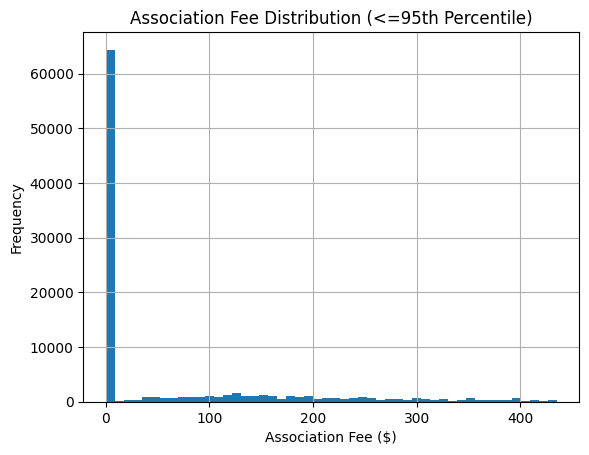

In [41]:
df_sf[
    df_sf["AssociationFee"] <= df_sf["AssociationFee"].quantile(0.95)
]["AssociationFee"].hist(bins=50)

plt.title("Association Fee Distribution (<=95th Percentile)")
plt.xlabel("Association Fee ($)")
plt.ylabel("Frequency")
plt.show()

### **NOTES**

AssociationFee is also highly right-skewed, and most properties have no fee or relatively low fees. Approximately 29% of the observations have missing values.

### **SUMMARY**

ListPrice, OriginalListPrice, ClosePrice, and LotSizeSquareFeet appear to be informative variables for predicting housing prices, and AssociationFee may require careful handling due to its missing values.

Variables with substantial missing values, like TaxAnnualAmount and TaxYear, may require removal during preprocessing.

In [42]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")


Saving 01_exploration.ipynb to 01_exploration.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>